# 日経レバ1579：月曜日アノマリー（シカゴ連動型）バックテスト

元ネタ：[Nikkei 225 Trading Strategy: Free Money Edge](https://breakouttradingacademy.com/this-strategy-is-like-printing-free-money-nikkei-225/)

## 戦略ロジック
シカゴ市場の月曜日（日本時間の月曜夜〜火曜早朝）に発生する日経平均先物の強力な上昇バイアスを、日本市場のETF（1579.T）で利益に変える戦略です。

*   **エントリー**: 月曜日の大引け（15:00）で成行買い
*   **エグジット**: 火曜日の寄付き（09:00）で成行売り
*   **目的**: シカゴの月曜セッションでの上昇を「窓開け」として取り込む。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# グラフのスタイル設定
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Meiryo', 'Yu Gothic', 'Hiragino Maru Gothic Pro', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

def load_moomoo_csv(filepath):
    df = pd.read_csv(filepath, thousands=',')
    column_map = {'日付': 'Date', '始値': 'Open', '高値': 'High', '安値': 'Low', '終値': 'Close'}
    df = df.rename(columns=column_map)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date').sort_index()
    return df

In [2]:
# データ読み込み（1579.T）
data_path_1579 = "../../moomoo/data/TimeChart(1579)20130509_20260502.csv"
df = load_moomoo_csv(data_path_1579)

# 2018年以降に限定（元ネタが指摘する近年の傾向を確認）
df = df[df.index >= "2018-01-01"]
df['day_of_week'] = df.index.dayofweek

## 1. 戦略の検証：月曜引け買い → 火曜寄り売り

このトレードのリターンは、**「火曜日の始値 - 月曜日の終値」**になります。
※日本株市場では火曜日のデータ（Open）に、月曜日のシカゴの動きが反映されます。

In [3]:
# 月曜日の終値を取得
monday_close = df[df['day_of_week'] == 0]['Close']

# 火曜日の始値を取得
tuesday_open = df[df['day_of_week'] == 1]['Open']

# 日付を合わせてリターンを計算（月曜日に買って火曜日に売る）
# monday_closeのインデックスは月曜、tuesday_openは火曜なので、
# tuesday_openを1日前にシフトして日付を合わせます
backtest_df = pd.DataFrame({
    'Buy_Price': monday_close,
    'Sell_Price': tuesday_open.shift(-1, freq='D') # 火曜のOpenを月曜の行に持ってくる
}).dropna()

backtest_df['Return'] = (backtest_df['Sell_Price'] - backtest_df['Buy_Price']) / backtest_df['Buy_Price']

print(f"検証回数: {len(backtest_df)}回")
print(f"勝率: {(backtest_df['Return'] > 0).mean():.2%}")
print(f"平均リターン: {backtest_df['Return'].mean():.4%}")
print(f"合計リターン: {backtest_df['Return'].sum():.2%}")

検証回数: 360回
勝率: 61.39%
平均リターン: 0.4664%
合計リターン: 167.89%


## 2. 他の曜日との比較（オーバーナイト）

「◯曜日の引けに買い、翌営業日の寄付きで売る」というトレードを全曜日で比較します。

C:\Users\user\AppData\Local\Temp\ipykernel_808\399848143.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison.index, y=comparison['平均リターン'], palette='viridis')


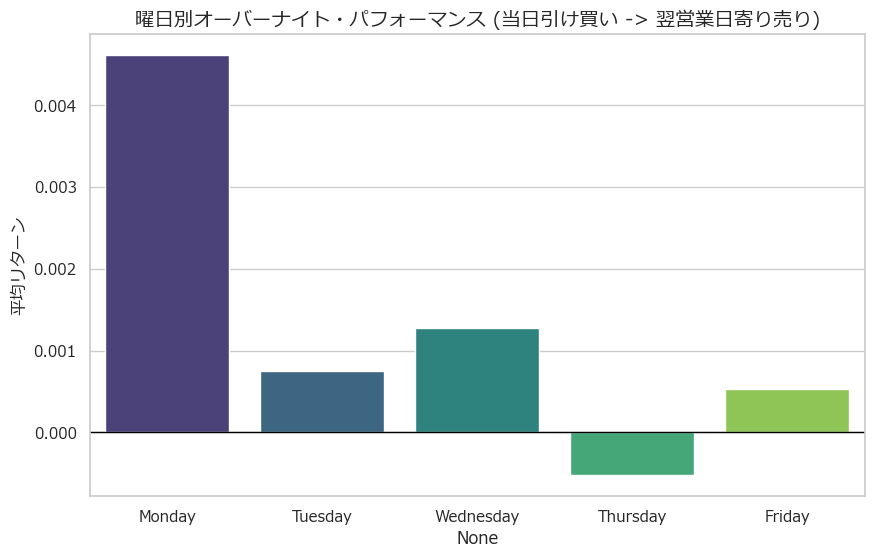

,平均リターン,勝率
Monday,0.461%,61.022%
Tuesday,0.075%,48.792%
Wednesday,0.128%,50.240%
Thursday,-0.052%,55.556%
Friday,0.053%,55.181%


In [4]:
df['next_open'] = df['Open'].shift(-1) # 翌営業日の始値
df['overnight_ret'] = (df['next_open'] - df['Close']) / df['Close']

weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
comparison = df.groupby('day_of_week')['overnight_ret'].agg(['mean', lambda x: (x > 0).mean()])
comparison.index = weekday_names
comparison.columns = ['平均リターン', '勝率']

plt.figure(figsize=(10, 6))
sns.barplot(x=comparison.index, y=comparison['平均リターン'], palette='viridis')
plt.title('曜日別オーバーナイト・パフォーマンス (当日引け買い -> 翌営業日寄り売り)', fontsize=14)
plt.axhline(0, color='black', lw=1)
plt.show()

display(comparison.style.format("{:.3%}"))

## 3. 累積リターンの推移

月曜日の大引けにだけ仕込み続けた場合の資産曲線を描画します。

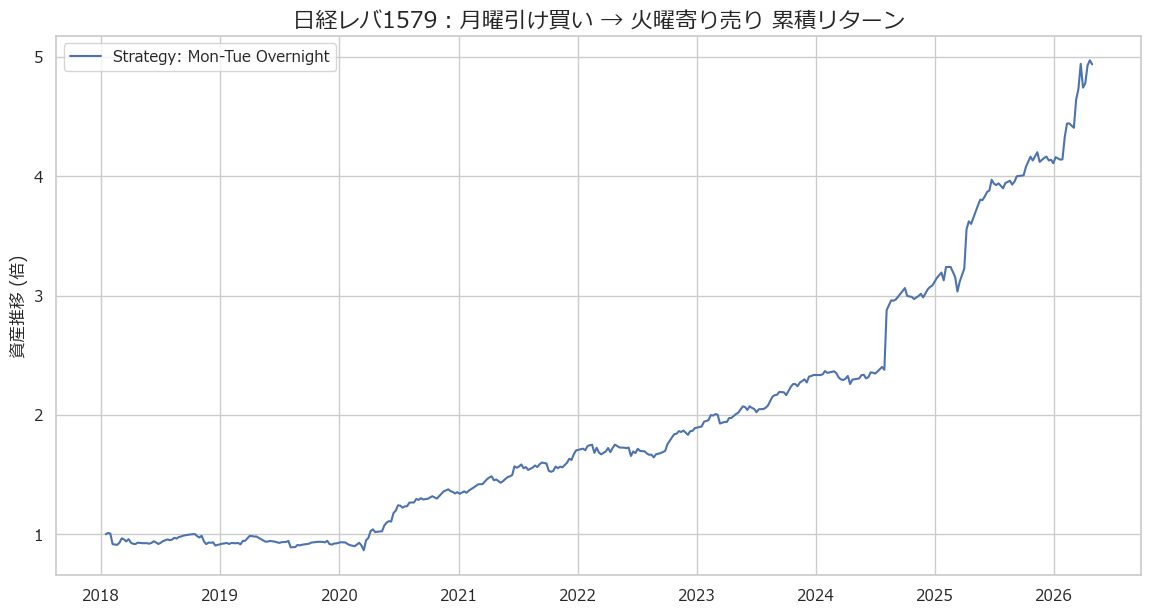

In [5]:
backtest_df['Equity'] = (1 + backtest_df['Return']).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(backtest_df.index, backtest_df['Equity'], label='Strategy: Mon-Tue Overnight')
plt.title('日経レバ1579：月曜引け買い → 火曜寄り売り 累積リターン', fontsize=16)
plt.ylabel('資産推移 (倍)')
plt.legend()
plt.show()

## 結論

- 元ネタの通り、月曜日から火曜日にかけてのオーバーナイトに優位性があるか確認してください。
- もしこの曲線が綺麗に右肩上がりであれば、シカゴ市場の月曜日バイアスが日本市場に「窓開け」として波及していることの証明になります。